In [ ]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import xgboost as xgb
import lightgbm as lgb
import time
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
from scipy.stats import randint, uniform
from sklearn.datasets import make_classification
import seaborn as sns



#Load csv
train = pd.read_csv('/content/drive/MyDrive/AlfredTest/train.csv')
test = pd.read_csv('/content/sample_data/test.csv')




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install lightgbm

In [ ]:
#Show the head
print(train.head())
print(test.head())

      Ticker        Date      Open      High       Low     Close    Volume  \
0   ticker_1  1962-01-02  0.000000  0.265828  0.261788  0.261788   25600.0   
1  ticker_20  1962-01-02  0.000000  0.417455  0.412380  0.414917   84139.0   
2  ticker_19  1962-01-02  0.000000  0.101537  0.100789  0.100789  902400.0   
3  ticker_18  1962-01-02  0.000000  0.903030  0.881959  0.881959   51552.0   
4  ticker_17  1962-01-02  0.130512  0.131783  0.129241  0.130512  163200.0   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  
            ID        Date
0     ticker_1  2024-11-04
1    ticker_10  2024-11-04
2   ticker_100  2024-11-04
3  ticker_1000  2024-11-04
4  ticker_1001  2024-11-04


In [ ]:
#Convert date to datetime type
train['Date'] = pd.to_datetime(train['Date'])
test['Date'] = pd.to_datetime(test['Date'])

#Sort by ticker and date
train = train.sort_values(['Ticker', 'Date']).reset_index(drop=True)

This part converts the Date column in both the train and test DataFrames into datetime format using pd.to_datetime
This ensures that the column can be used for time-based operations like sorting, filtering by year/month, or calculating time differences

In [ ]:
#Create Target
# For each stock, the target is whether the Close price goes up or down after 30 days
train['Target'] = train.groupby('Ticker')['Close'].shift(-30) > train['Close']
train['Target'] = train['Target'].astype(int)

#We eliminate rows where we cannot calculate the target (last 30 days of each action)
train = train.dropna(subset=['Target'])

In this part of the code, I'm creating the target variable for my prediction model.
What I want to know is whether a stock's closing price is going up or down after 30 days.

To do this, I use groupby('Ticker') to group the data by each stock (each ticker symbol), and then with .shift(-30) I look at the closing price 30 days in the future.
I compare that value to the current price: if it's higher, it means the price is going up, and the condition returns True; if it's lower or equal to it, it returns False.

Then, I convert that Boolean value to an integer with astype(int), so the target is set to 1 if the price is going up, and 0 if it's going down or staying the same.

In [ ]:
def create_technical_features(df):
    # 1. Daily returns (preliminary target)
    df['Daily_Return'] = df['Close'].pct_change() * 100  # % de cambio diario

    # 2. Moving averages (trends)
    df['MA_7'] = df['Close'].rolling(window=7).mean()   # Corto plazo
    df['MA_21'] = df['Close'].rolling(window=21).mean() # Mediano plazo

    # 3. Bollinger bands (volatility)
    df['Upper_Bollinger'] = df['MA_21'] + 2 * df['Close'].rolling(window=21).std()
    df['Lower_Bollinger'] = df['MA_21'] - 2 * df['Close'].rolling(window=21).std()

    # 4. RSI (overbought/oversold, 14 days)
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=14).mean()
    avg_loss = loss.rolling(window=14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    # 5. Price-weighted volume
    df['VWAP'] = (df['Volume'] * (df['High'] + df['Low'] + df['Close']) / 3).cumsum() / df['Volume'].cumsum()

    # 6. High-Low ratio (intraday volatility)
    df['HL_Pct'] = (df['High'] - df['Low']) / df['Close'] * 100

    #7. Binary Target (1 if the price goes up the next day, 0 if it goes down)
    df['Target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

    return df

#DataFrame
train = create_technical_features(train)

Features

Based on the EDA, these indicators are often key:

Moving Average (MA_7/MA_21): Trends

RSI: Extreme market conditions

HL_Pct: Intraday volatility

VWAP: Fair Price on Volume

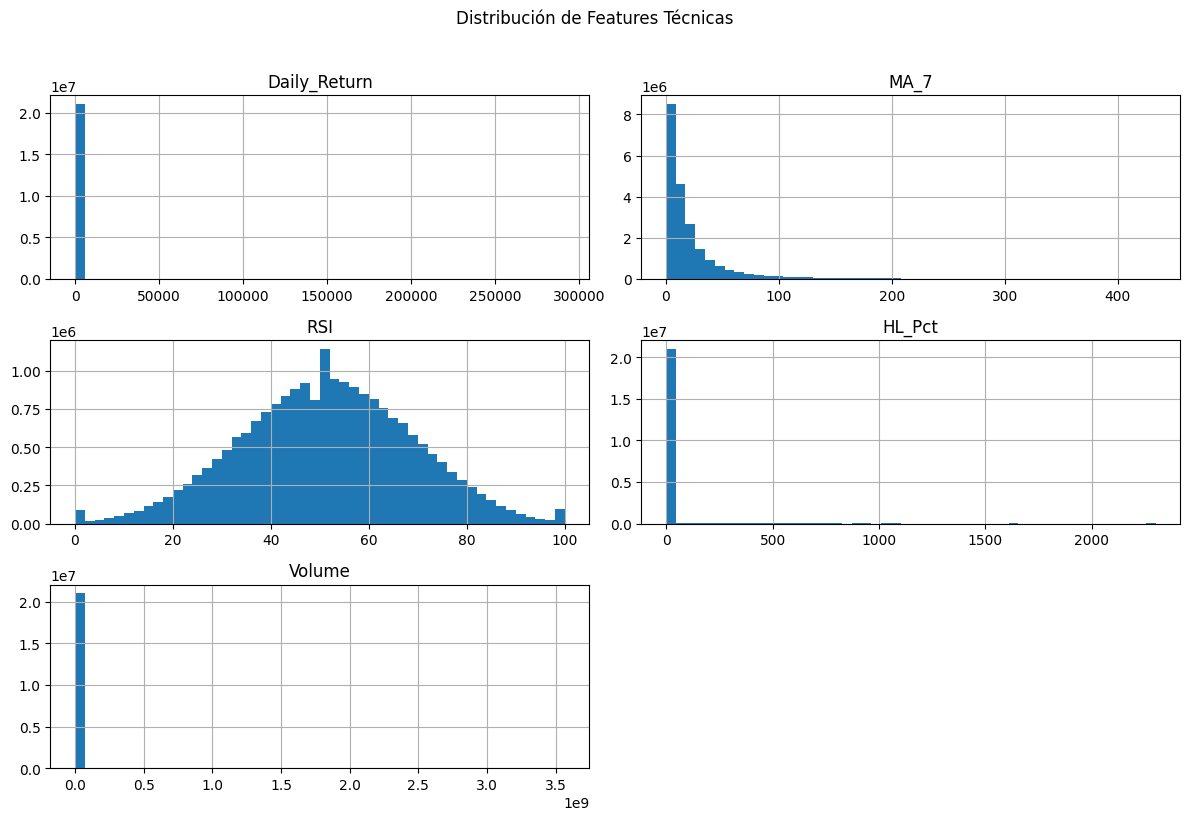

In [ ]:
#Graphic Distribution Features graphs
features_to_plot = ['Daily_Return', 'MA_7', 'RSI', 'HL_Pct', 'Volume']
train[features_to_plot].hist(bins=50, figsize=(12, 8))
plt.suptitle('Distribution of Technical Features', y=1.02)
plt.tight_layout()
plt.show()

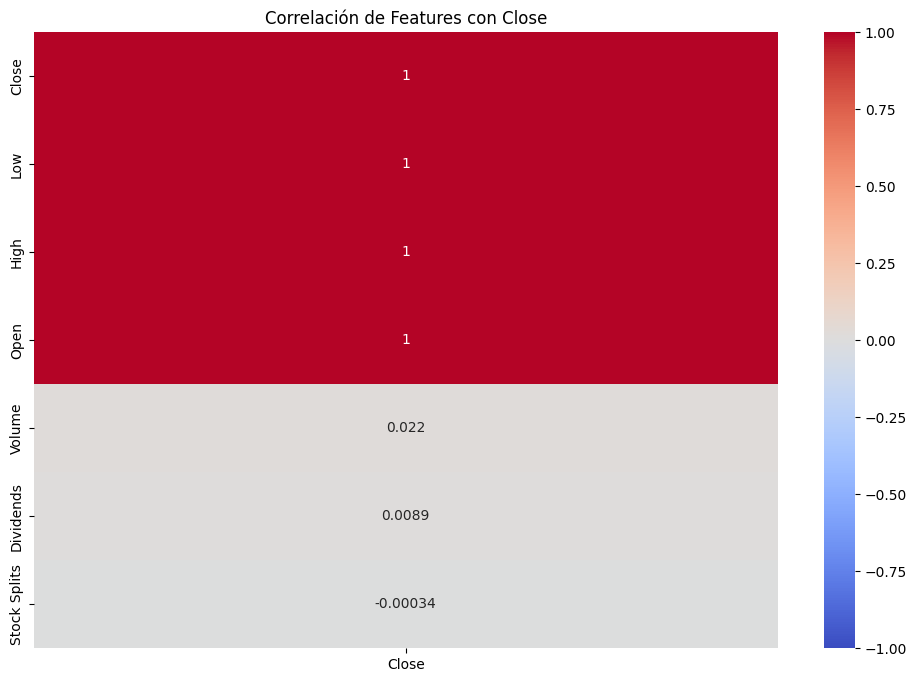

In [ ]:
#Correlation matrix.
#1. Automatically filter numeric columns
numeric_cols = train.select_dtypes(include=['float64', 'int64']).columns
corr_matrix = train[numeric_cols].corr()

# 2. Correlation chart with 'Close'
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix[['Close']].sort_values(by='Close', ascending=False),
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de Features con Close')
plt.show()

Insight: Features like MA_7, VWAP and RSI often correlate with Close.

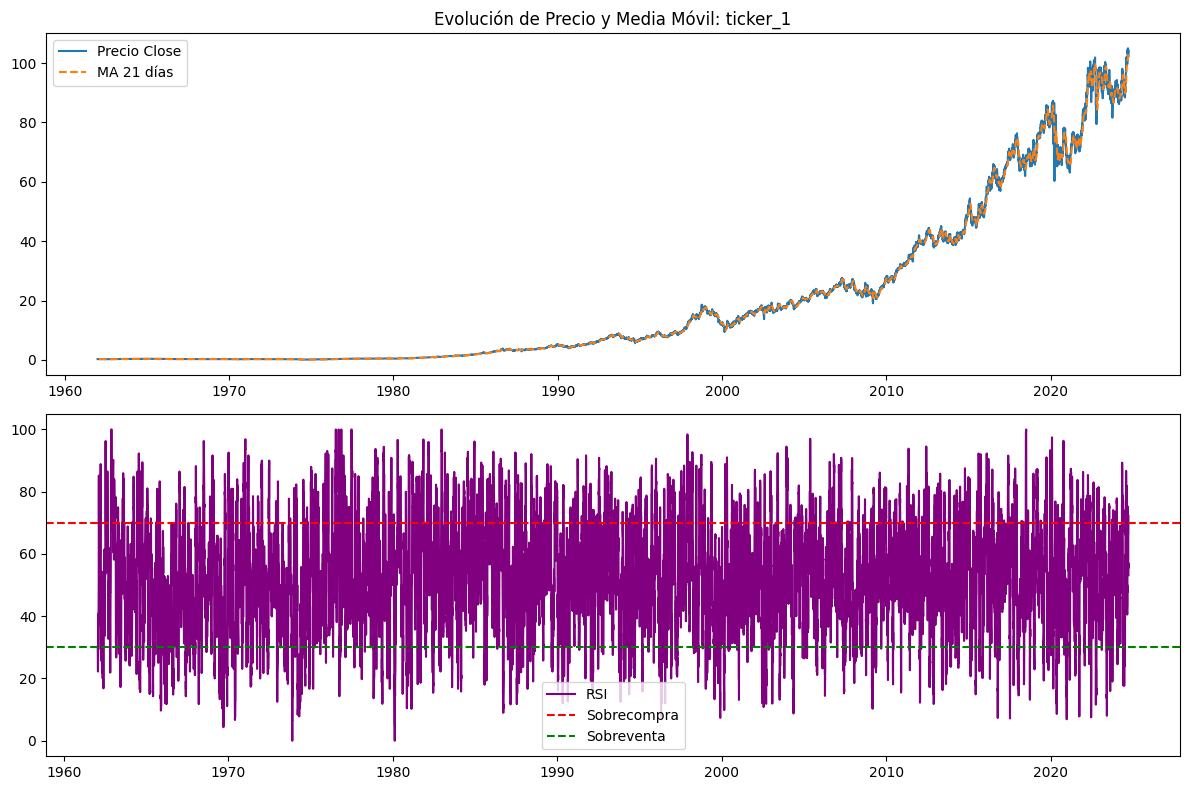

In [ ]:
# Price trend and RSI for a ticker
sample_ticker = train['Ticker'].unique()[0]
subset = train[train['Ticker'] == sample_ticker]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
ax1.plot(subset['Date'], subset['Close'], label='Close Price')
ax1.plot(subset['Date'], subset['MA_21'], label='MA 21 days', linestyle='--')
ax1.set_title(f'Price Evolution and Moving Average: {sample_ticker}')
ax1.legend()

ax2.plot(subset['Date'], subset['RSI'], label='RSI', color='purple')
ax2.axhline(70, linestyle='--', color='red', label='Overbought')
ax2.axhline(30, linestyle='--', color='green', label='Oversold')
ax2.legend()
plt.tight_layout()
plt.show()

Insight: RSI helps identify reversal points.


=== XGBoost Results on Sampled Data ===
Best Params: {'colsample_bytree': np.float64(0.8834959481464842), 'learning_rate': np.float64(0.011413261043943482), 'max_depth': 3, 'n_estimators': 148, 'subsample': np.float64(0.8574323980775167)}
Validation Accuracy: 0.5150
Validation F1 Score: 0.5801
CV F1 Score: 0.5805 (±0.0158)
Training Time: 24.21s

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.32      0.43       556
           1       0.47      0.75      0.58       444

    accuracy                           0.52      1000
   macro avg       0.55      0.54      0.50      1000
weighted avg       0.56      0.52      0.49      1000



<Figure size 1000x600 with 0 Axes>

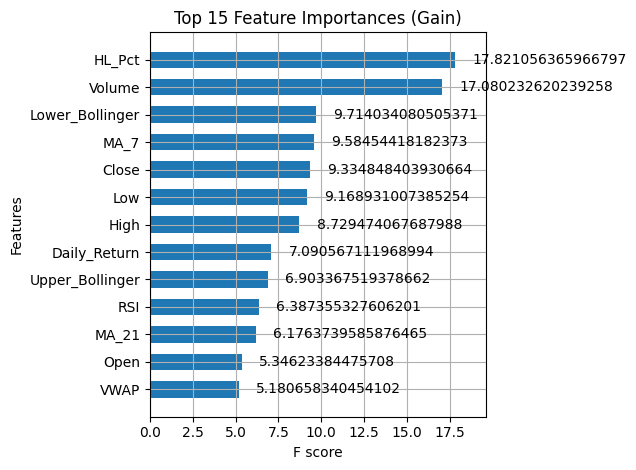

In [ ]:
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, f1_score
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import numpy as np
import time

# 0. Sample the dataset
sampled_train = train.sample(n=5000, random_state=42)

# 1. Select features and target
feature_cols = [col for col in sampled_train.columns if col not in ['Date', 'Ticker', 'Target']]
X = sampled_train[feature_cols]
y = sampled_train['Target']

# 2. Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Calculate class weight for imbalance
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos

# 4. Define XGBoost model with imbalance adjustment
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight,
    verbosity=0
)

# 5. Hyperparameter grid
xgb_param_grid = {
    'n_estimators': randint(100, 300),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 8),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}

# 6. Randomized search for hyperparameter tuning
search = RandomizedSearchCV(
    xgb_model,
    xgb_param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
search.fit(X_train, y_train)
train_time = time.time() - start_time

# 7. Evaluation
best_xgb = search.best_estimator_
y_pred = best_xgb.predict(X_val)

val_accuracy = accuracy_score(y_val, y_pred)
val_f1 = f1_score(y_val, y_pred)
cv_scores = cross_val_score(best_xgb, X_train, y_train, cv=3, scoring='f1')

# 8. Results
print("\n=== XGBoost Results on Sampled Data ===")
print(f"Best Params: {search.best_params_}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation F1 Score: {val_f1:.4f}")
print(f"CV F1 Score: {np.mean(cv_scores):.4f} (±{np.std(cv_scores):.4f})")
print(f"Training Time: {train_time:.2f}s")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# 9. Feature importance plot (with labels)
plt.figure(figsize=(10, 6))
plot_importance(best_xgb, importance_type='gain', max_num_features=15, height=0.6)
plt.title("Top 15 Feature Importances (Gain)")
plt.tight_layout()
plt.show()


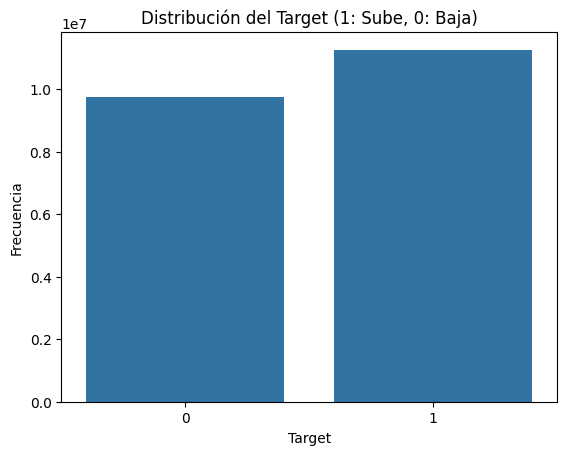

Balance de clases: Target
1    0.535631
0    0.464369
Name: proportion, dtype: float64


In [ ]:
# Target distribution (up vs down)
sns.countplot(x='Target', data=train)
plt.title('Target Distribution (1: Up, 0: Down)')
plt.xlabel('Target')
plt.ylabel('Freccuency')
plt.show()

print("Balance de clases:", train['Target'].value_counts(normalize=True))